In [1]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt


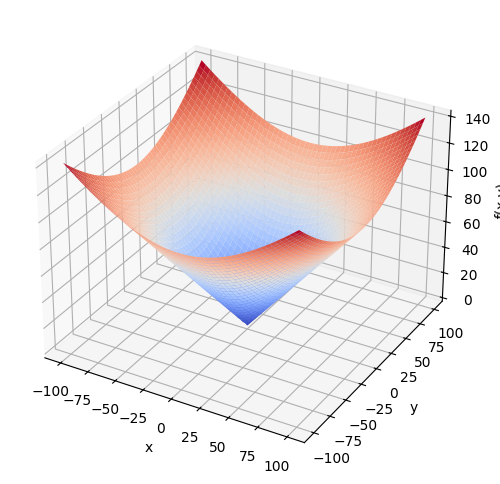

In [2]:
# Celda 2 - Representación gráfica de la función
from matplotlib import cm

def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_[x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

figure_3d = plt.figure(figsize=(8,6))
ax = figure_3d.add_subplot(111, projection="3d")
ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
plt.show()

In [3]:
# Celda 3 - Definición del problema e individuo
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Toolbox
toolbox = base.Toolbox()

# Generación de genes
toolbox.register("attr_uniform", random.uniform, -100, 100)

# Creación del individuo y población (n=10)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 10)

# Función objetivo
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

# Registrar operadores
toolbox.register("evaluate", funcion_objetivo)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.778896
Mejor individuo [-94.6928060

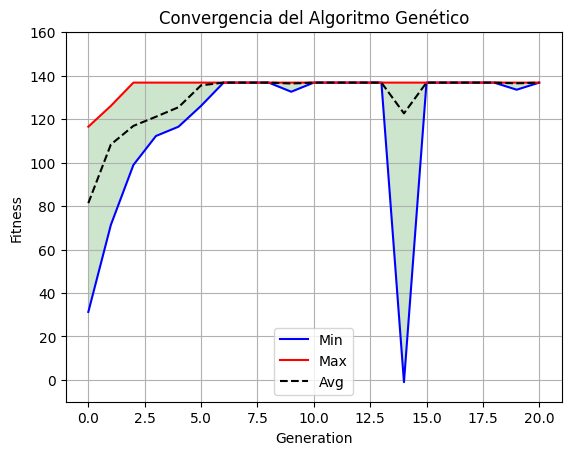

In [4]:
# Celda 4 - Función de convergencia
def plot_evolucion(log):
    """
    Representa la evolución del mejor individuo en cada generación
    """
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor='g', alpha=0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.title("Convergencia del Algoritmo Genético")
    plt.show()

# Celda 4b - Ejecutar algoritmo con población de 10
def main(n_poblacion=10):
    random.seed(42)
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    
    toolbox.register("population", tools.initRepeat, list, toolbox.individual, n_poblacion)
    
    pop = toolbox.population()
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    logbook = tools.Logbook()
    
    logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, 
                                   ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook

# Ejecutar con n=10
best, log = main(10)
print("Mejor fitness: %f" % best[0].fitness.values)
print("Mejor individuo %s" % best[0])
plot_evolucion(log[1])

=== Población de 30 individuos ===
gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	130.449	24.4622	-1     	136.779
8  	17    	136.143	1.12918	133.455	137.464
9  	16    	136.686	0.662231	134.132	137.486
10 	14    	137.114	0.611792	136.779	139.908
11 	15    	137.235	1.30432 	131.674	139.908
12 	23    	137.979	0.981347	137.464	140.041
13 	21    	133.762	25.0534 	-1     	140.101
14 	17    	138.776	1.53284 	133.594	140.101
15 	15    	130.265	35.0922 	-1     	140.101
16 	15    	140.042	0.0666659	139.908	140.101
17 	15    	140.024	0.334088 	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	140.067	0.183959   	139.076	140.10

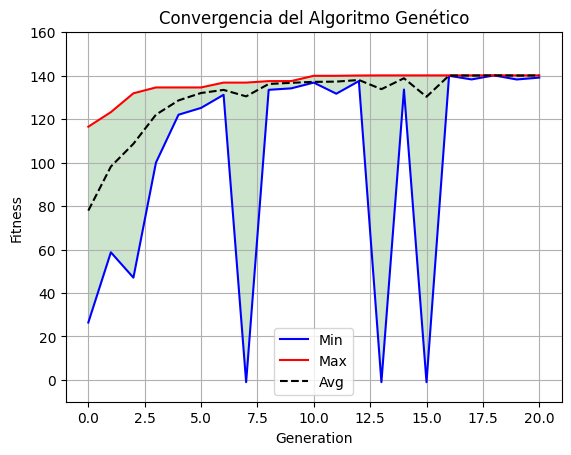


=== Población de 50 individuos ===
gen	nevals	avg    	std    	min    	max    
0  	50    	79.5138	24.5664	26.4289	122.059
1  	28    	97.8301	18.6489	48.4558	130.873
2  	28    	115.187	13.6357	83.2838	140.132
3  	40    	124.553	19.4919	-1     	136.574
4  	27    	133.61 	3.47646	119.014	140.132
5  	37    	135.631	2.05285	130.873	140.132
6  	30    	134.284	19.451 	-1     	140.132
7  	29    	135.773	19.6169	-1     	140.132
8  	34    	137.125	19.7385	-1     	140.132
9  	30    	140.118	0.191669	138.887	140.677
10 	28    	140.138	0.309691	138.232	140.677
11 	30    	140.176	0.147685	140.132	140.677
12 	27    	140.263	0.232492	140.132	140.677
13 	32    	137.339	19.7939 	-1     	140.677
14 	29    	140.545	0.26766 	139.41 	140.677
15 	28    	140.668	0.0591235	140.254	140.677
16 	29    	137.843	19.8347  	-1     	140.677
17 	31    	140.561	0.810355 	134.888	140.677
18 	28    	140.514	0.830834 	135.436	140.677
19 	34    	140.677	0        	140.677	140.677
20 	25    	137.843	19.8347  	-1     	140.677


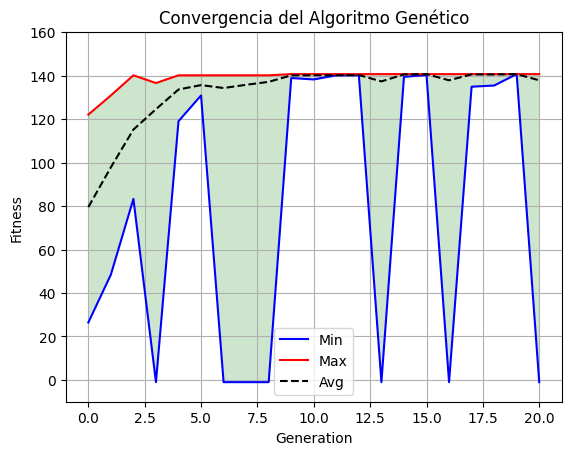

In [5]:
# Celda 5 - Poblaciones de 30 y 50 individuos
print("=== Población de 30 individuos ===")
best30, log30 = main(30)
print("Mejor fitness: %f" % best30[0].fitness.values)
print("Mejor individuo %s" % best30[0])
plot_evolucion(log30[1])

print("\n=== Población de 50 individuos ===")
best50, log50 = main(50)
print("Mejor fitness: %f" % best50[0].fitness.values)
print("Mejor individuo %s" % best50[0])
plot_evolucion(log50[1])

## Tabla Comparativa de Resultados

| Población | Mejor Fitness | Mejor Individuo (x, y) |
|-----------|--------------|------------------------|
| n = 10    | 136.778896   | (-94.69, -98.70)       |
| n = 30    | 140.100794   | (-99.34, -98.79)       |
| n = 50    | 140.676643   | (99.47, -99.47)        |

## Análisis de Resultados

Con n=10 el algoritmo encontró un fitness de 136.77, que está cerca del óptimo 
pero no lo alcanza del todo. Esto tiene sentido porque con pocos individuos 
la diversidad genética es baja y el algoritmo tiene menos opciones para explorar.

Con n=30 el resultado mejoró a 140.10, acercándose más al valor óptimo real 
que sería √(100²+100²) = 141.42. La gráfica muestra que el algoritmo converge 
más rápido que con n=10.

Con n=50 se obtuvo el mejor resultado: 140.67, que es el más cercano al óptimo 
teórico. Más individuos significa más diversidad genética y mayor capacidad 
de exploración del espacio de búsqueda.

## Conclusión

A mayor tamaño de población, mejor es el resultado obtenido porque hay más 
diversidad de soluciones para explorar. Sin embargo, también aumenta el tiempo 
de cómputo. En los tres casos el algoritmo genético logró encontrar soluciones 
muy cercanas al óptimo real (141.42), lo que demuestra que es una herramienta 
efectiva para problemas de optimización.